# 问题二、三、四｜原版山地色带、三维航线与救援时效

代码、工作DEM、原始数据和图均在此 notebook 的同级目录；顺序运行即可重新生成。

## 一眼看结果

- **问题二**：19架次末箱6803秒、返航7319秒；时间优先22架次末箱6227秒、返航6899秒。
- **问题三**：22次运输＋4次中继，末箱6227秒、联合返航6936秒，连续通信核验通过。
- **问题四**：严格不复制中继时三组无非单站解；专属中继副本下两组8／7区缺5件，三组4／6／5区缺9件。

下列所有**19张交付图**均由本 notebook 自顶向下执行生成和检查；原图存放在链接所示相对路径。

## 数据与方法

Q2：19架次经济情景与经原始DEM验证的22架次时间情景；22架次固定航线和设备先后次序，仅重排Q2时刻。Q3：独立核验22＋4连续通信方案。Q4：先核验严格中继不复制口径，再明确采用各组专属的完整中继任务副本。Q4不得改变Q3运输时刻；所有地图继续使用原工作DEM、RdYlBu_r色带及原V7三维相机。

In [1]:
from pathlib import Path
import sys, subprocess, json, hashlib, io
from PIL import Image as PILImage
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
assert (ROOT/'q3_source/q1_flat/最终工作DEM.tif').is_file()
FIGURES = {'问题二': ['q2_source/time_priority_3d/问题二_原版视角三维_19与22架次_航线机型.png', 'q2_source/time_priority_3d/问题二_原版视角三维_19与22架次_三时段.png', 'figures/时效图05_问题二原色带_真实时间缩短对比.png', 'figures/时效图01_问题二_逐箱硬余量及返航.png', 'q2_source/time_priority_3d/原版问题二_22架次时序图/认证更新_图04_联合调度与资源峰值.png', 'q2_source/time_priority_3d/原版问题二_22架次时序图/认证更新_图06_装载能耗与返航余量.png', 'q2_source/time_priority_3d/原版问题二_22架次时序图/认证更新_图07_交付进度与时限保障.png'], '问题三': ['figures/问题三_时间主方案_三维_图03_六面板三维山地航线.png', 'figures/问题三_时间主方案_地图_图01_九面板通信空间图.png', 'figures/时效图02_问题三_逐箱硬余量及返航.png', 'figures/时效图03_问题三候选_5百分比容许差.png', 'figures/问题三_时间主方案_图02_运输与中继联合资源时序.png', 'figures/问题三_时间主方案_图07_逐箱交付与资源核验.png'], '问题四': ['q4_updated/no_singletons/figures/问题四_图01_原色带DEM_两组三组分区.png', 'q4_updated/no_singletons/figures/问题四_图02_原视角三维地形与固定航线.png', 'q4_updated/no_singletons/figures/问题四_图03_原版三维地形与八类资源缺口.png', 'q4_updated/no_singletons/figures/问题四_图04_原配色DEM飞行时间与分组蜂巢图.png', 'q4_updated/no_singletons/figures/问题四_图05_原DEM分组空间椭圆.png', 'q4_updated/no_singletons/figures/问题四_图06_原版时序资源峰值.png']}
RUNS = []

def run(script, *args):
    script = ROOT / script
    assert script.is_file(), script
    command = [sys.executable, '-X', 'utf8', str(script), *map(str, args)]
    completed = subprocess.run(command, cwd=script.parent, capture_output=True, text=True)
    info = {'script': str(script.relative_to(ROOT)), 'returncode': completed.returncode,
            'stdout_tail': completed.stdout[-900:], 'stderr_tail': completed.stderr[-500:]}
    RUNS.append(info)
    print(('通过  ' if completed.returncode == 0 else '失败  ') + info['script'])
    if completed.returncode: print(completed.stdout[-3000:], completed.stderr[-3000:])
    completed.check_returncode()

def show(question, start=0, stop=None):
    for rel in FIGURES[question][start:stop]:
        path = ROOT/rel
        with PILImage.open(path) as original:
            original.load()
            preview = original.copy()
            preview.thumbnail((950, 730), PILImage.Resampling.LANCZOS)
            buf = io.BytesIO(); preview.save(buf, format='PNG', optimize=True)
        display(Markdown(f'**[{path.name}]({rel})**'))
        display(Image(data=buf.getvalue()))

print('实际 Jupyter 内核：', sys.version.split()[0], '；工作目录：', ROOT.name)

实际 Jupyter 内核： 3.12.14 ；工作目录： Time_Priority_Q2_Q3_Q4


## 问题二｜优化、独立复核与七张图

In [2]:
run('q2_source/time_priority_3d/solve_q2_fast22.py')
run('q2_source/time_priority_3d/问题二_真正时间优先_原始DEM独立核验.py')
run('q2_source/priority_scenarios/复核分情景选解.py')
q2 = json.loads((ROOT/'q2_source/time_priority_3d/问题二_真正时间优先_原始DEM独立核验.json').read_text(encoding='utf-8'))
assert q2['status']=='通过' and (q2['verified_sorties'],q2['verified_boxes'])==(22,80)
assert (q2['last_delivery_s'],q2['all_return_s'],q2['min_hard_slack_s'])==(6227,6899,230)
print('Q2 独立原始DEM核验：末箱',q2['last_delivery_s'],'秒；返航',q2['all_return_s'],'秒')

通过  q2_source/time_priority_3d/solve_q2_fast22.py


通过  q2_source/time_priority_3d/问题二_真正时间优先_原始DEM独立核验.py


通过  q2_source/priority_scenarios/复核分情景选解.py
Q2 独立原始DEM核验：末箱 6227 秒；返航 6899 秒


通过  q2_source/time_priority_3d/plot_q2_original_terrain_3d.py


通过  q2_source/priority_scenarios/original_q2_plots/认证更新_调度装载交付.py


通过  plot_time_decisions.py


**[问题二_原版视角三维_19与22架次_航线机型.png](q2_source/time_priority_3d/问题二_原版视角三维_19与22架次_航线机型.png)**

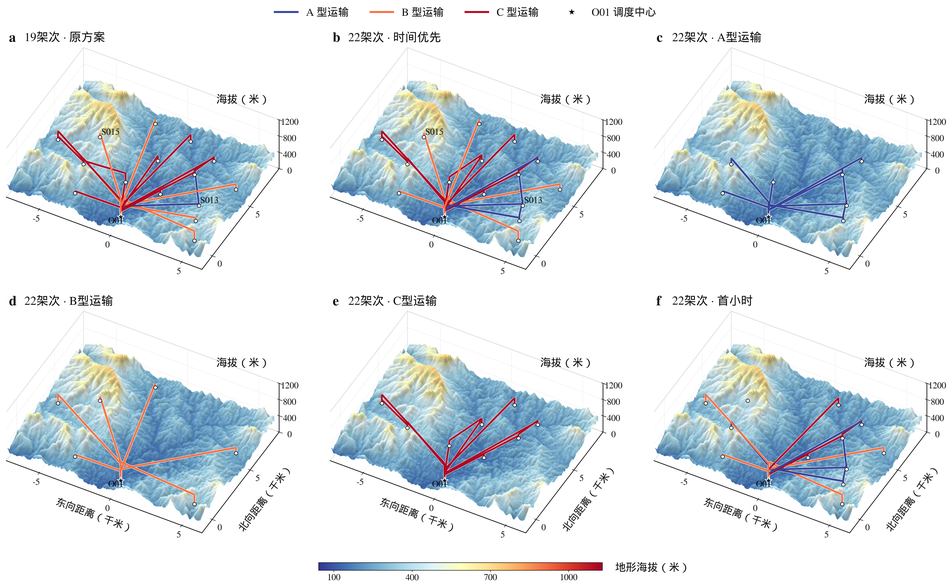

**[问题二_原版视角三维_19与22架次_三时段.png](q2_source/time_priority_3d/问题二_原版视角三维_19与22架次_三时段.png)**

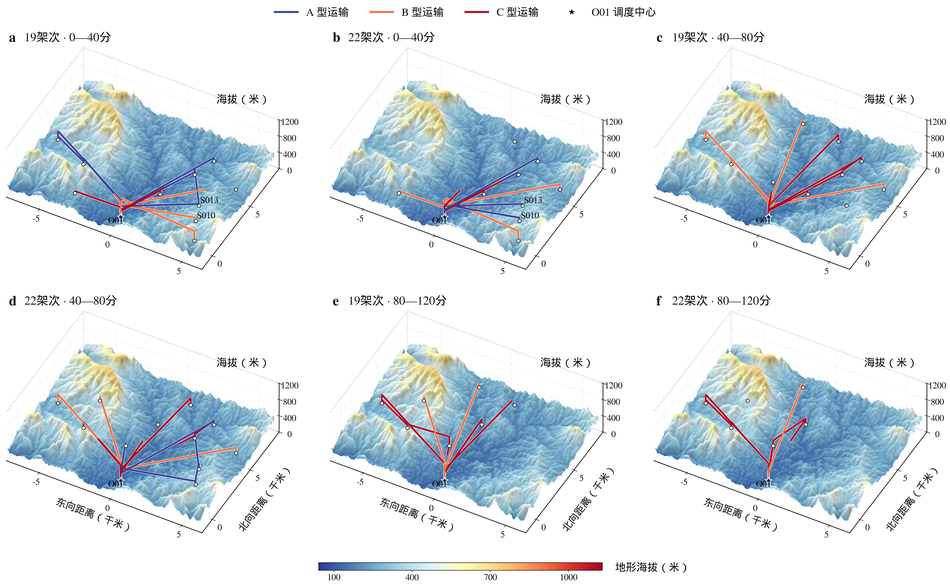

**[时效图05_问题二原色带_真实时间缩短对比.png](figures/时效图05_问题二原色带_真实时间缩短对比.png)**

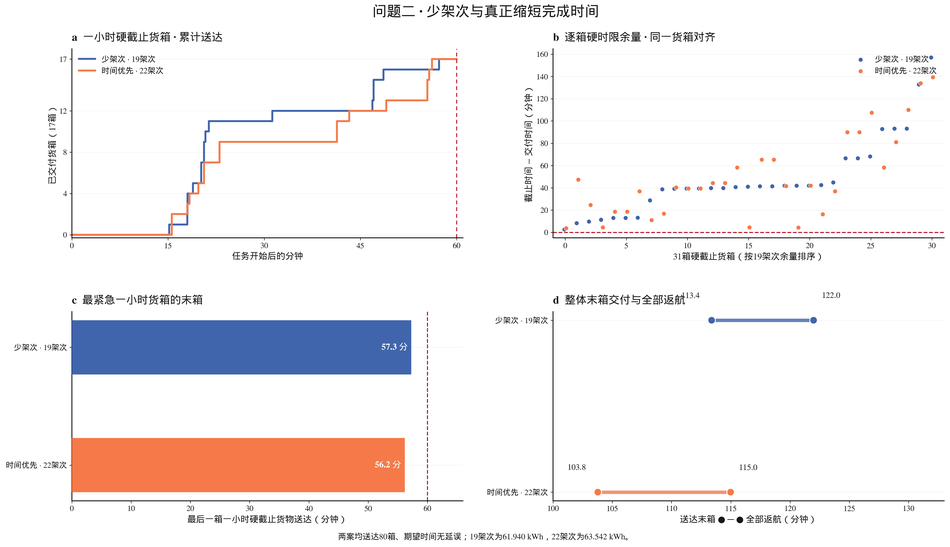

**[时效图01_问题二_逐箱硬余量及返航.png](figures/时效图01_问题二_逐箱硬余量及返航.png)**

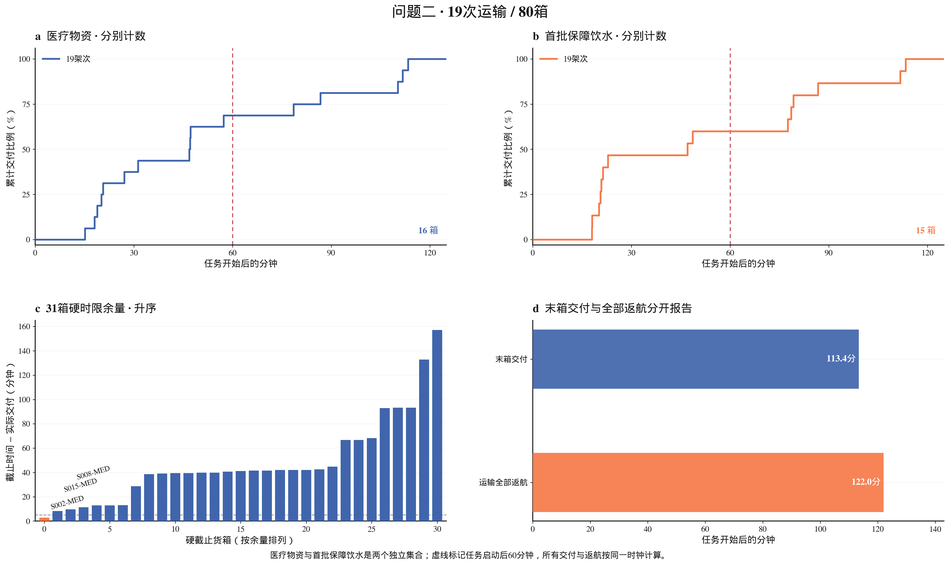

**[认证更新_图04_联合调度与资源峰值.png](q2_source/time_priority_3d/原版问题二_22架次时序图/认证更新_图04_联合调度与资源峰值.png)**

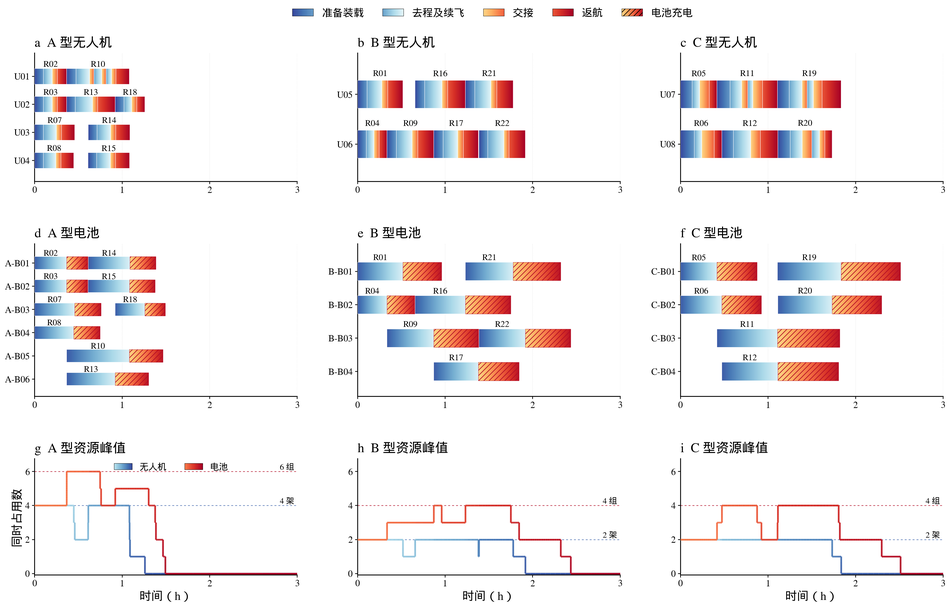

**[认证更新_图06_装载能耗与返航余量.png](q2_source/time_priority_3d/原版问题二_22架次时序图/认证更新_图06_装载能耗与返航余量.png)**

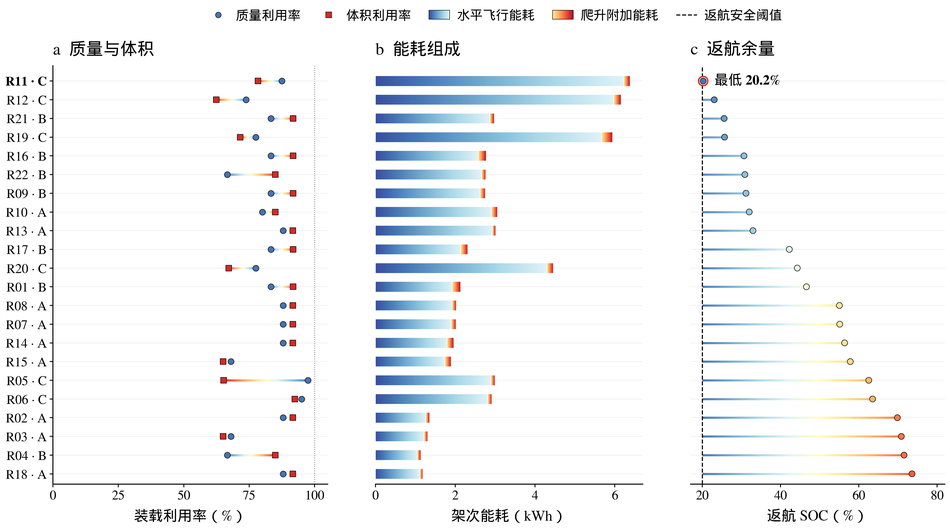

**[认证更新_图07_交付进度与时限保障.png](q2_source/time_priority_3d/原版问题二_22架次时序图/认证更新_图07_交付进度与时限保障.png)**

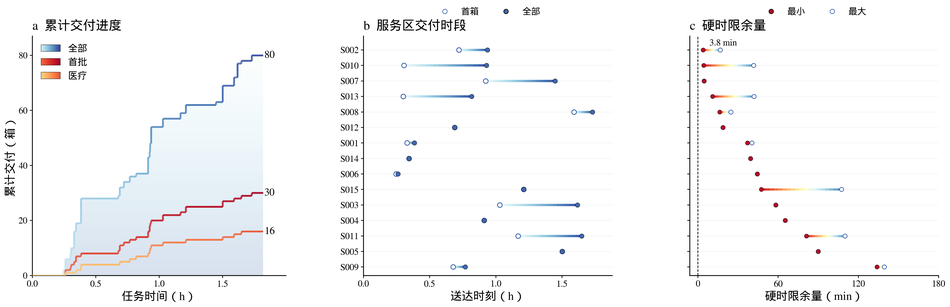

In [3]:
run('q2_source/time_priority_3d/plot_q2_original_terrain_3d.py')
run('q2_source/priority_scenarios/original_q2_plots/认证更新_调度装载交付.py',
    '--source', ROOT/'q2_source/time_priority_3d/问题二_真正时间优先_22架次',
    '--output',ROOT/'q2_source/time_priority_3d/原版问题二_22架次时序图', '--dpi','240')
run('plot_time_decisions.py')
show('问题二')

## 问题三｜连续通信核验与六张图

问题三的时刻未改用Q2重排结果；分别检查运输、中继、资源和完整返航。

In [4]:
run('q3_source/问题三_V3_结果核验.py','--prefix','问题三_时间主方案')
q3 = json.loads((ROOT/'q3_source/问题三_时间主方案_结果.json').read_text(encoding='utf-8'))
com = json.loads((ROOT/'q3_source/问题三_时间主方案_V3_独立核验.json').read_text(encoding='utf-8'))
assert (q3['N_transport'],q3['N_relay'])==(22,4)
assert (q3['last_delivery_s'],q3['joint_finish_s'])==(6227,6936)
assert com['status']=='全部通过' and com['精确通信核验']['failed_coverage_count']==0
print('Q3：22+4，连续通信覆盖缺口0，联合返航6936秒')

通过  q3_source/问题三_V3_结果核验.py
Q3：22+4，连续通信覆盖缺口0，联合返航6936秒


通过  q3_source/问题三_V4_统计绘图.py


通过  q3_source/问题三_V7_六面板三维山地航线.py


通过  q3_source/问题三_V4_地图绘图.py


**[问题三_时间主方案_三维_图03_六面板三维山地航线.png](figures/问题三_时间主方案_三维_图03_六面板三维山地航线.png)**

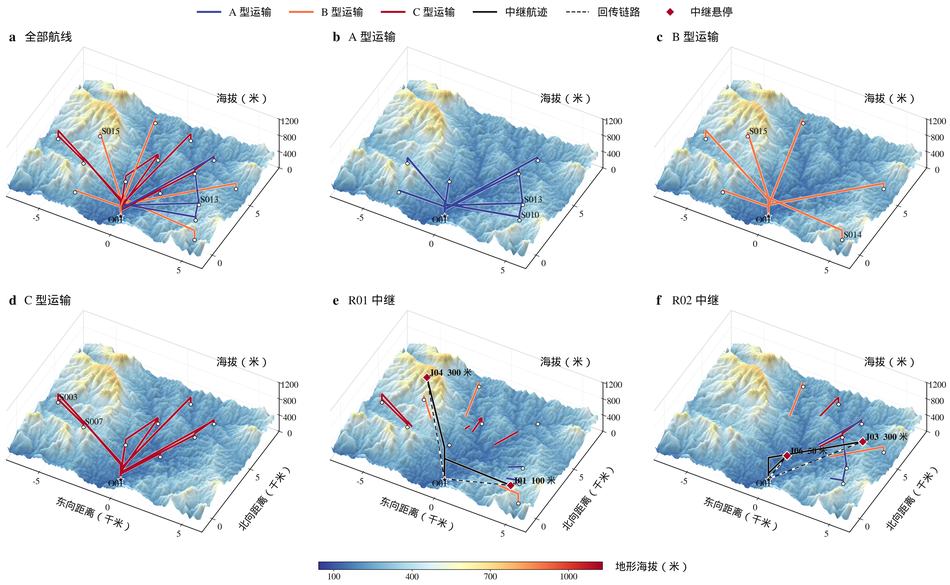

**[问题三_时间主方案_地图_图01_九面板通信空间图.png](figures/问题三_时间主方案_地图_图01_九面板通信空间图.png)**

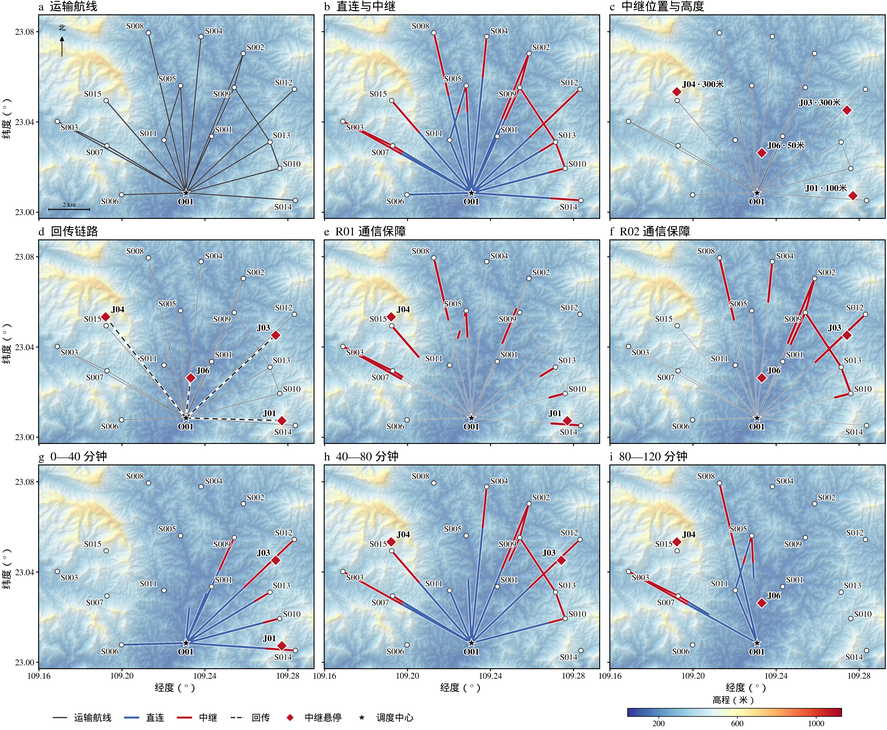

**[时效图02_问题三_逐箱硬余量及返航.png](figures/时效图02_问题三_逐箱硬余量及返航.png)**

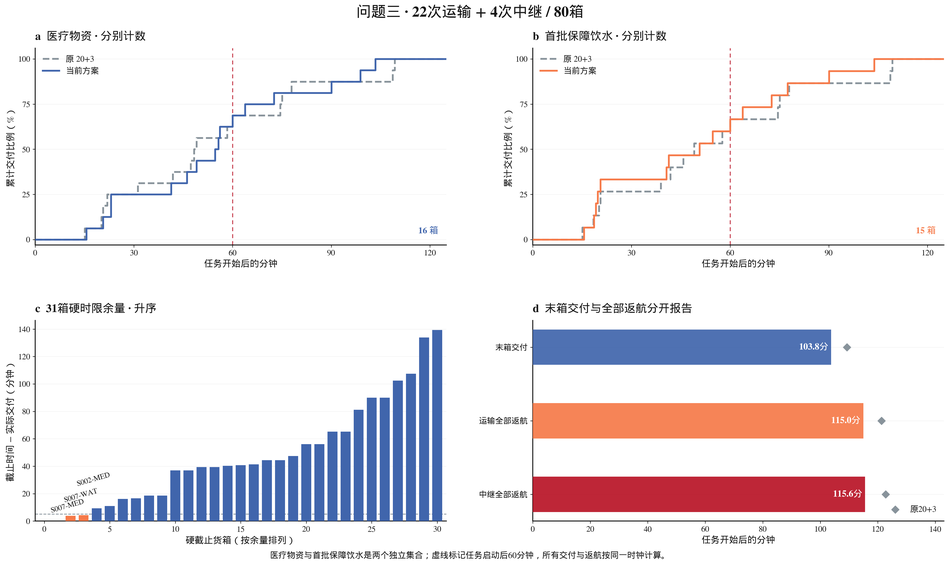

**[时效图03_问题三候选_5百分比容许差.png](figures/时效图03_问题三候选_5百分比容许差.png)**

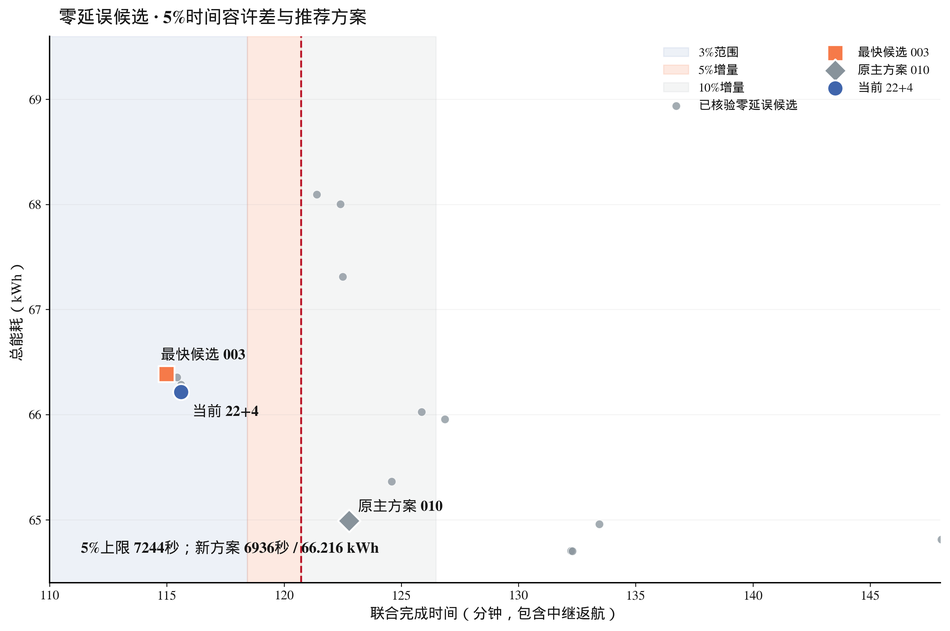

**[问题三_时间主方案_图02_运输与中继联合资源时序.png](figures/问题三_时间主方案_图02_运输与中继联合资源时序.png)**

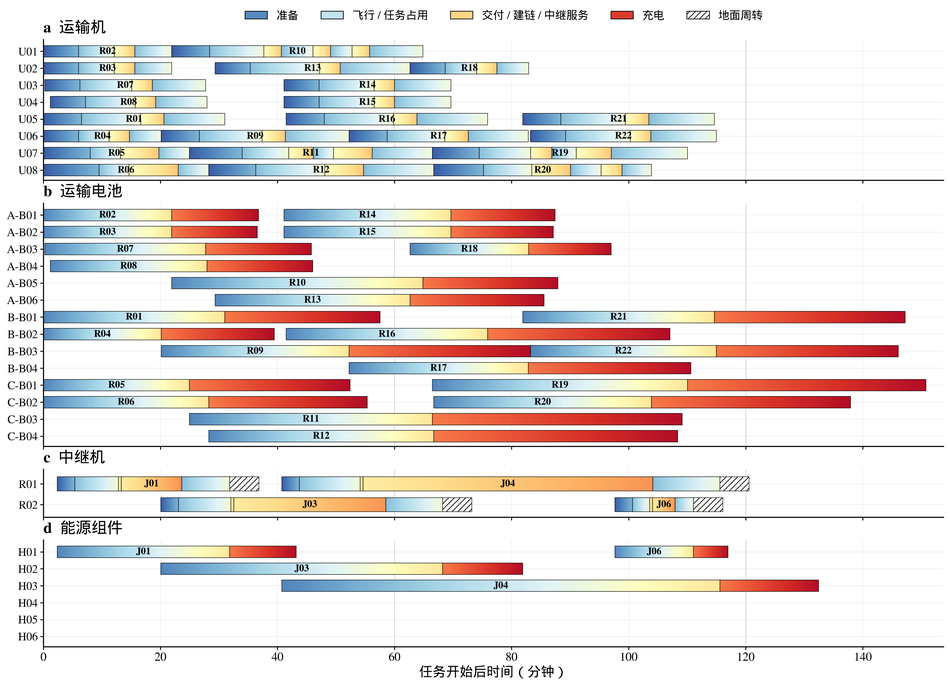

**[问题三_时间主方案_图07_逐箱交付与资源核验.png](figures/问题三_时间主方案_图07_逐箱交付与资源核验.png)**

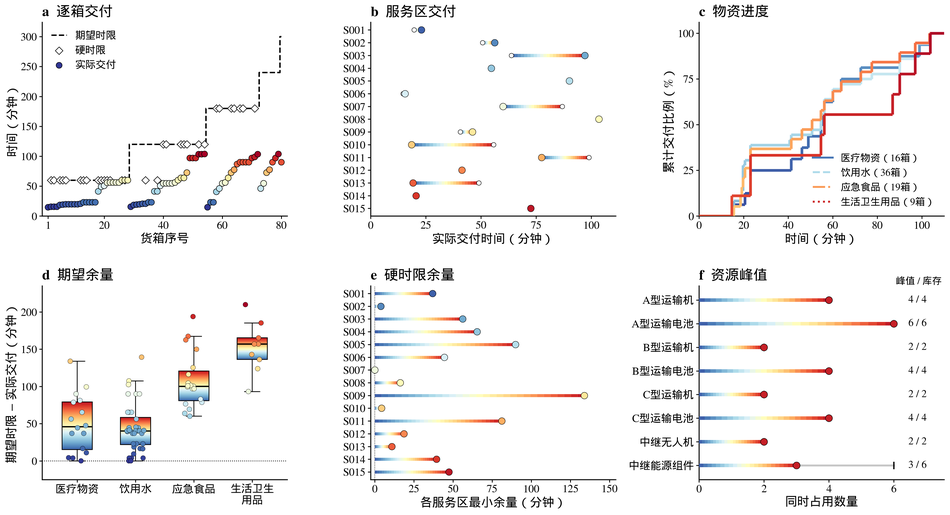

In [5]:
run('q3_source/问题三_V4_统计绘图.py', '--prefix','问题三_时间主方案',
    '--output-prefix',ROOT/'figures/问题三_时间主方案','--dpi','260')
run('q3_source/问题三_V7_六面板三维山地航线.py','--prefix','问题三_时间主方案',
    '--geometry','问题三_时间主方案_精确',
    '--output-prefix',ROOT/'figures/问题三_时间主方案_三维','--dpi','230')
run('q3_source/问题三_V4_地图绘图.py','--prefix','问题三_时间主方案',
    '--geometry','问题三_时间主方案_精确','--stations','问题三_V3_站点.csv',
    '--output-prefix',ROOT/'figures/问题三_时间主方案_地图','--dpi','220')
show('问题三')

## 问题四｜固定任务分区、库存缺口与六张图

无单站组结果属于**显式复制组内中继任务**的情景。严格不复制时三组无解；分组本身不会缩短问题三的6227秒／6936秒。

In [6]:
run('q4_updated/compute_q4.py','--source',ROOT/'q3_source',
    '--output',ROOT/'q4_updated/data')
run('q4_updated/compute_q4_spatial.py','--q3-dir',ROOT/'q3_source',
    '--data-dir',ROOT/'q4_updated/data')
run('q4_updated/compute_q4_no_singletons.py')
base=json.loads((ROOT/'q4_updated/data/qa.json').read_text(encoding='utf-8'))
q4=json.loads((ROOT/'q4_updated/no_singletons/results.json').read_text(encoding='utf-8'))
assert base['status']=='PASS' and base['recommendations']=={'2':'K2_02','3':None}
assert q4['checks']['cp_sat_optimal'] and q4['checks']['no_single_site_group']
assert q4['base_q3']['last_joint_return_s']==6936
print('Q4：严格三组不可行；专属中继副本情景 CP-SAT 与枚举复核通过')

通过  q4_updated/compute_q4.py


通过  q4_updated/compute_q4_spatial.py


通过  q4_updated/compute_q4_no_singletons.py
Q4：严格三组不可行；专属中继副本情景 CP-SAT 与枚举复核通过


通过  q4_updated/plot_q4_no_singletons_maps.py


通过  q4_updated/plot_q4_no_singletons_answer.py


通过  q4_updated/plot_q4_no_singletons_hex.py


通过  q4_updated/plot_q4_no_singletons_ellipses.py


通过  q4_updated/plot_q4_no_singletons_timeline.py


**[问题四_图01_原色带DEM_两组三组分区.png](q4_updated/no_singletons/figures/问题四_图01_原色带DEM_两组三组分区.png)**

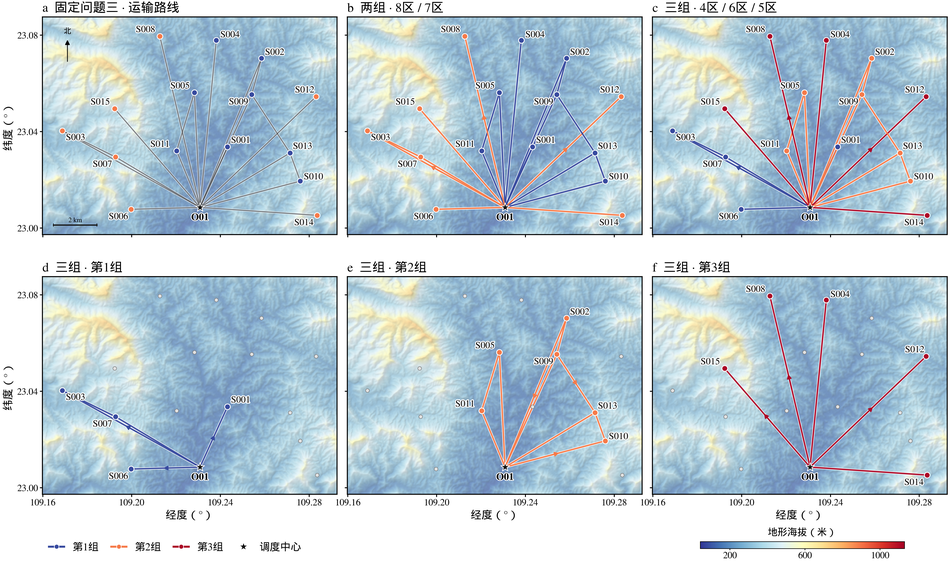

**[问题四_图02_原视角三维地形与固定航线.png](q4_updated/no_singletons/figures/问题四_图02_原视角三维地形与固定航线.png)**

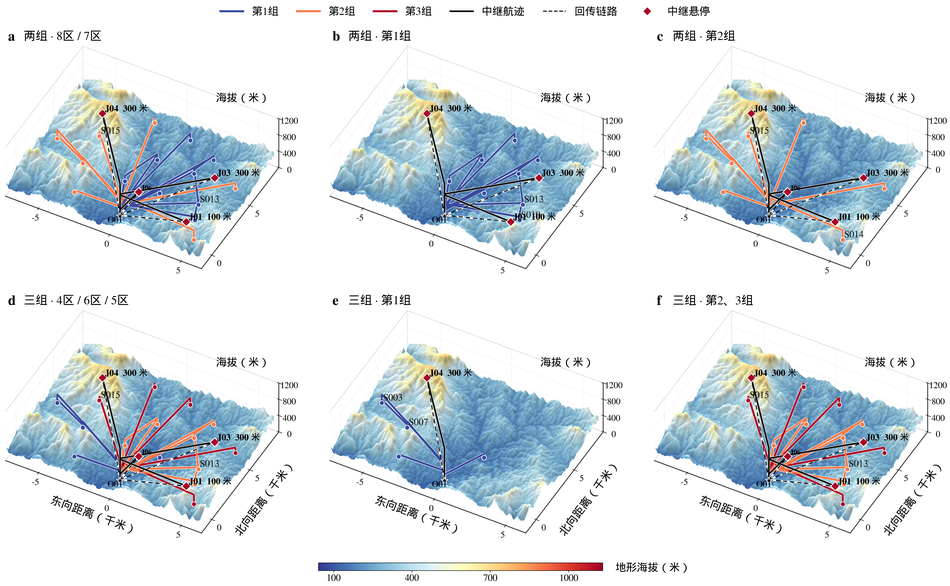

**[问题四_图03_原版三维地形与八类资源缺口.png](q4_updated/no_singletons/figures/问题四_图03_原版三维地形与八类资源缺口.png)**

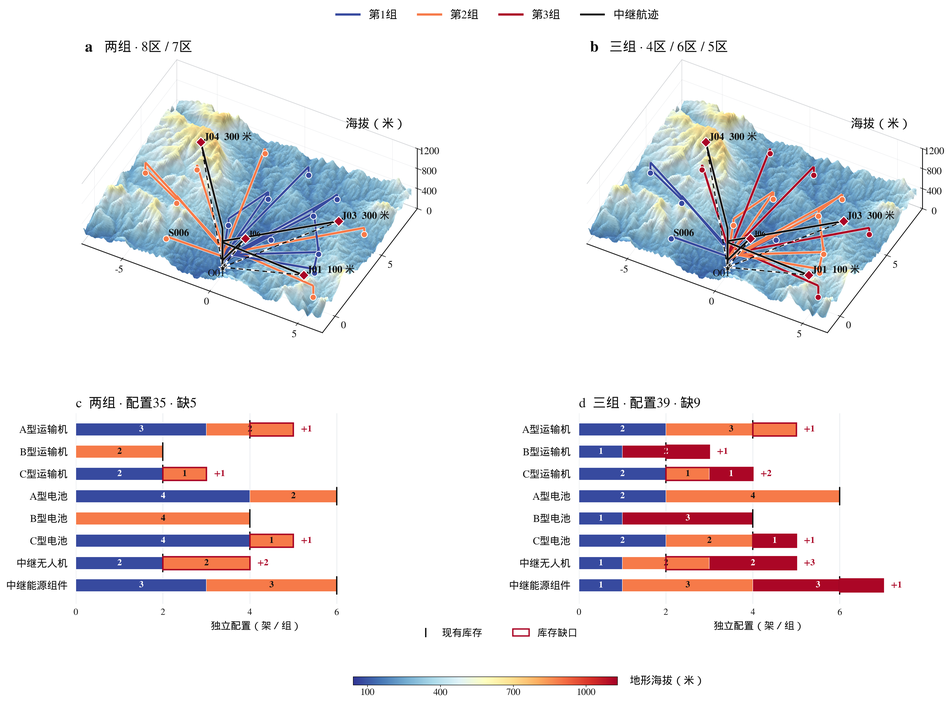

**[问题四_图04_原配色DEM飞行时间与分组蜂巢图.png](q4_updated/no_singletons/figures/问题四_图04_原配色DEM飞行时间与分组蜂巢图.png)**

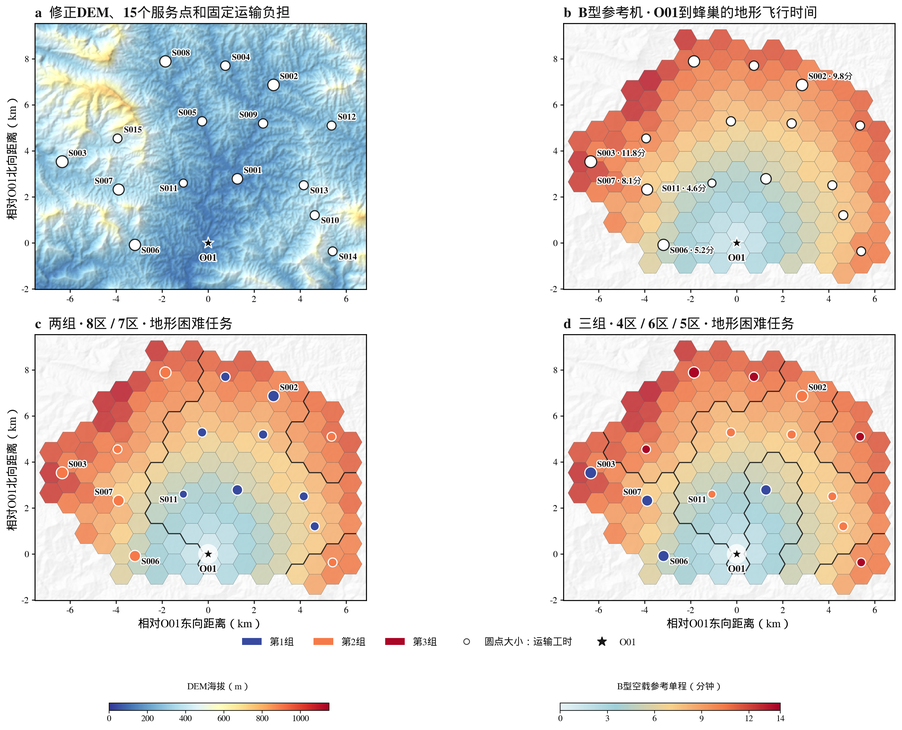

**[问题四_图05_原DEM分组空间椭圆.png](q4_updated/no_singletons/figures/问题四_图05_原DEM分组空间椭圆.png)**

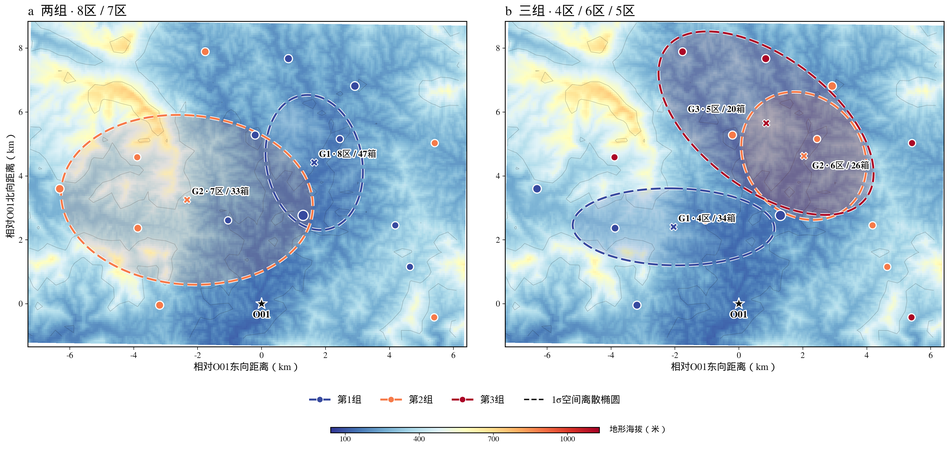

**[问题四_图06_原版时序资源峰值.png](q4_updated/no_singletons/figures/问题四_图06_原版时序资源峰值.png)**

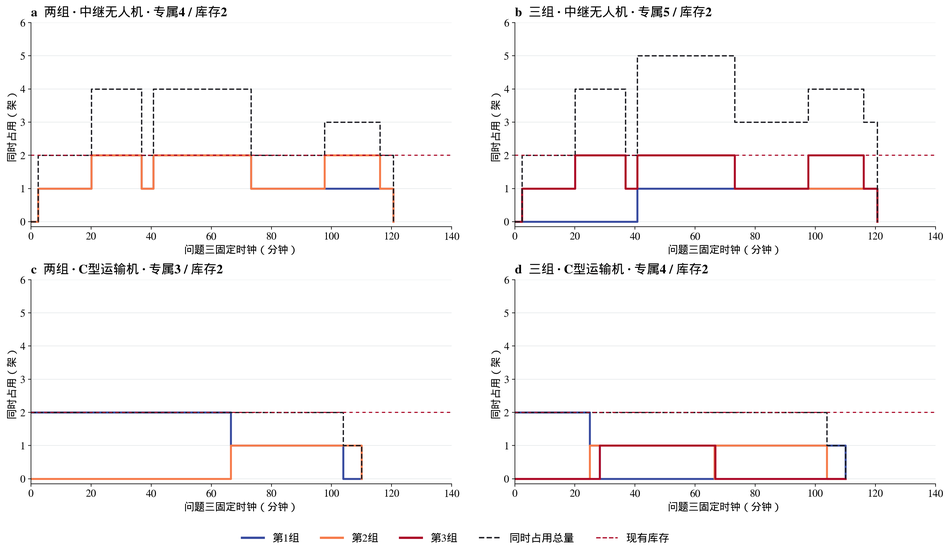

In [7]:
for script in ('plot_q4_no_singletons_maps.py','plot_q4_no_singletons_answer.py',
               'plot_q4_no_singletons_hex.py','plot_q4_no_singletons_ellipses.py',
               'plot_q4_no_singletons_timeline.py'):
    run('q4_updated/'+script)
show('问题四')

## 逐图验证与结论

In [8]:
figure_hashes = {}
for question, figures in FIGURES.items():
    for rel in figures:
        path=ROOT/rel
        assert path.exists() and path.stat().st_size>10000,rel
        with PILImage.open(path) as picture:
            picture.verify()
        figure_hashes[rel]=hashlib.sha256(path.read_bytes()).hexdigest()
    print(question, len(figures), '张：全部成功重绘并通过PNG检查')
assert len(figure_hashes)==19 and all(a['returncode']==0 for a in RUNS)
print('合计19张图；Q2返航提前420秒、末箱提前576秒；Q3全部通信覆盖通过。')

问题二 7 张：全部成功重绘并通过PNG检查
问题三 6 张：全部成功重绘并通过PNG检查
问题四 6 张：全部成功重绘并通过PNG检查
合计19张图；Q2返航提前420秒、末箱提前576秒；Q3全部通信覆盖通过。
